<a href="https://colab.research.google.com/github/HanaaMaswada/Student-Success-Prediction-and-Clustering-Analysis/blob/main/Student_Success_Prediction_and_Clustering_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Part 1 - Step 1: Load Data

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Option_B_clustering - Option_B_clustering.csv')

df.head()

Step 2: Explore Data

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()

Step 3: Prepare Data

In [ ]:
X = df.drop('passed_course', axis=1)

Step 4: Scale Data

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Step 5: Elbow Method

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

Step 6: Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores.append(score)

    print(f'k={k}, silhouette={score:.4f}')

Step 7: Plot Silhouette

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), scores, marker='o')

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')

plt.show()

Select the Optimal Number of Clusters

The Elbow Method showed a noticeable reduction in inertia around k=5. However, the highest Silhouette Score (0.1668) was achieved when k=2. Since the Silhouette Score directly measures cluster separation and cohesion, k=2 was selected as the optimal number of clusters.

Build the Final K-Means Model

In [ ]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

Analyze Cluster Characteristics

Cluster Sizes

In [ ]:
df['Cluster'].value_counts()

Cluster Summary

In [ ]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

cluster_summary.T

Visualization 1: PCA Cluster Projection

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['Cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.title('Student Clusters (PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.colorbar(label='Cluster')

plt.show()

Figure 1 shows the student clusters projected onto two principal components using PCA. The visualization demonstrates that the K-Means algorithm successfully separated the students into two distinct groups. Most of the separation occurs along the first principal component, indicating that this dimension captures the main differences between student characteristics. Although some overlap exists near the cluster boundary, the overall clustering structure appears meaningful and supports the selection of two clusters.

In [ ]:
assessment_cols = [
    'assess_score_1',
    'assess_score_2',
    'assess_score_3',
    'assess_score_4',
    'assess_score_5'
]

cluster_summary.loc[:, assessment_cols].T.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Average Assessment Scores by Cluster')
plt.ylabel('Average Score')
plt.xlabel('Assessment')
plt.legend(title='Cluster')
plt.show()

Figure 2 compares the average assessment scores across the five assessments for each cluster. Students in Cluster 1 consistently achieved higher scores in all assessments, with average scores ranging from approximately 80 to 87. In contrast, students in Cluster 0 obtained lower average scores, ranging from approximately 60 to 65. The results indicate that academic performance is a major factor separating the two clusters. Cluster 1 appears to represent high-performing students, while Cluster 0 represents students with weaker academic outcomes.

#Cluster Analysis
##Cluster 0
Cluster 0 contains 4,301 students and represents the lower-performing group. These students achieved lower assessment scores across all assessments and had a lower course pass rate (58%). They also had slightly more previous course attempts and lower education levels compared with Cluster 1. Overall, this cluster appears to represent students who may be at greater academic risk.

##Cluster 1

Cluster 1 contains 8,436 students and represents the higher-performing group. These students achieved consistently higher assessment scores and had a much higher course pass rate (86%). They generally had higher education levels, fewer previous attempts, and came from slightly less deprived backgrounds. This cluster represents students with stronger academic performance and a greater likelihood of successfully completing the course.

##Choice of Number of Clusters

The optimal number of clusters was selected as K=2. The Silhouette Score reached its highest value (0.1668) when K=2, indicating the best separation between clusters. In addition, the Elbow Method showed a noticeable reduction in inertia before the curve began to flatten. Therefore, K=2 was selected as the most appropriate number of clusters for segmenting the students.

Visualization 2: Assessment Performance

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Cluster',
    y='assess_score_5'
)

plt.title('Assessment Score 5 by Cluster')

plt.show()

The boxplot demonstrates a clear difference in Assessment Score 5 between the two clusters. Cluster 1 students generally achieved higher scores, with a median around 90, while Cluster 0 students achieved lower scores, with a median around 60. The higher concentration of scores in the upper range for Cluster 1 indicates stronger academic performance. Therefore, assessment results appear to play a significant role in distinguishing the student groups identified by K-Means clustering.

#Part 2: Modeling

Step 1: Load Modeling Dataset

In [26]:
from google.colab import files

uploaded = files.upload()

Saving Option_B_modeling.csv to Option_B_modeling.csv


In [27]:
import pandas as pd

df = pd.read_csv('/content/Option_B_modeling.csv')

df.head()

,gender,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,passed_course,assess_score_1,assess_score_2,...,module_CCC,module_DDD,module_EEE,module_FFF,module_GGG,presentation_0,presentation_2013B,presentation_2013J,presentation_2014B,presentation_2014J
0,1,2,9,2,0,240,0,1,78.0,85.0,...,0,0,0,0,0,0,0,1,0,0
1,0,2,2,1,0,60,0,1,70.0,68.0,...,0,0,0,0,0,0,0,1,0,0
2,0,3,5,1,0,60,0,1,72.0,71.0,...,0,0,0,0,0,0,0,1,0,0
3,0,1,5,0,0,60,0,1,69.0,30.0,...,0,0,0,0,0,0,0,1,0,0
4,1,2,3,0,0,60,0,1,70.0,65.0,...,0,0,0,0,0,0,0,1,0,0


2. Explore Data

In [28]:
df.shape

df.info()

df['passed_course'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12737 entries, 0 to 12736
Columns: 931 entries, gender to presentation_2014J
dtypes: float64(910), int64(21)
memory usage: 90.5 MB


,count
passed_course,
1,9720
0,3017


3. Check Missing Values

In [29]:
df.isnull().sum().sum()

np.int64(0)

4. Define Features and Target

In [30]:
X = df.drop('passed_course', axis=1)

y = df['passed_course']

5. Train-Test Split

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

6. Scale Data

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

7. Apply PCA

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

print("Original Features:", X_train.shape[1])
print("PCA Features:", X_train_pca.shape[1])

Original Features: 930
PCA Features: 493


Model 1

Build Model

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model1 = Sequential([
    Dense(32,
          activation='relu',
          input_shape=(X_train_pca.shape[1],)),
    Dense(1,
          activation='sigmoid')
])

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │        15,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,841 (61.88 KB)

 Trainable params: 15,841 (61.88 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [35]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

history1 = model1.fit(
    X_train_pca,
    y_train,
    validation_split=0.2,
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8246 - loss: 0.4347 - val_accuracy: 0.8440 - val_loss: 0.3901
Epoch 2/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8808 - loss: 0.2947 - val_accuracy: 0.8582 - val_loss: 0.3800
Epoch 3/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9004 - loss: 0.2515 - val_accuracy: 0.8548 - val_loss: 0.3846
Epoch 4/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9123 - loss: 0.2207 - val_accuracy: 0.8538 - val_loss: 0.3921
Epoch 5/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9281 - loss: 0.1943 - val_accuracy: 0.8548 - val_loss: 0.4064
Epoch 6/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9357 - loss: 0.1709 - val_accuracy: 0.8474 - val_loss: 0.4283
Epoch 7/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9447 - loss: 0.1497 - val_accuracy: 0.8513 - val_loss: 0.4413


Plot History

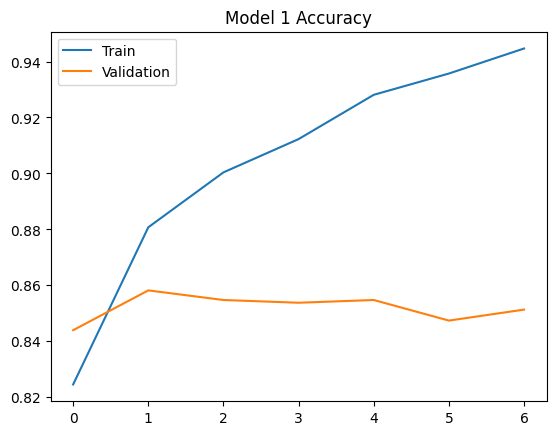

In [36]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])

plt.legend(['Train','Validation'])
plt.title('Model 1 Accuracy')
plt.show()

Evaluate Model


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.77      0.64      0.70       616
           1       0.89      0.94      0.91      1932

    accuracy                           0.87      2548
   macro avg       0.83      0.79      0.81      2548
weighted avg       0.86      0.87      0.86      2548



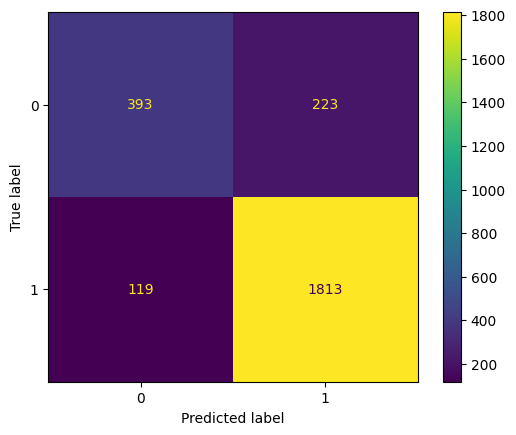

In [37]:
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_prob = model1.predict(X_test_pca)

y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test,y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

##Model 2

Build Model 2

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model2 = Sequential()

model2.add(Dense(
    64,
    activation='relu',
    input_shape=(X_train_pca.shape[1],)
))

model2.add(Dropout(0.3))

model2.add(Dense(
    32,
    activation='relu'
))

model2.add(Dense(
    1,
    activation='sigmoid'
))

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │        31,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,729 (131.75 KB)

 Trainable params: 33,729 (131.75 KB)

 Non-trainable params: 0 (0.00 B)

Train Model 2

In [40]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

history2 = model2.fit(
    X_train_pca,
    y_train,
    validation_split=0.2,
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8066 - loss: 0.4561 - val_accuracy: 0.8489 - val_loss: 0.3737
Epoch 2/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8684 - loss: 0.3268 - val_accuracy: 0.8538 - val_loss: 0.3638
Epoch 3/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8887 - loss: 0.2792 - val_accuracy: 0.8557 - val_loss: 0.3684
Epoch 4/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9006 - loss: 0.2476 - val_accuracy: 0.8562 - val_loss: 0.3791
Epoch 5/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9087 - loss: 0.2249 - val_accuracy: 0.8572 - val_loss: 0.3814
Epoch 6/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9169 - loss: 0.2093 - val_accuracy: 0.8597 - val_loss: 0.3920
Epoch 7/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9258 - loss: 0.1876 - val_accuracy: 0.8587 - val_loss: 0.4138
Epoch 8/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9313 - loss: 0.1750 - val_accuracy: 0.

Visualize Model 2 Training

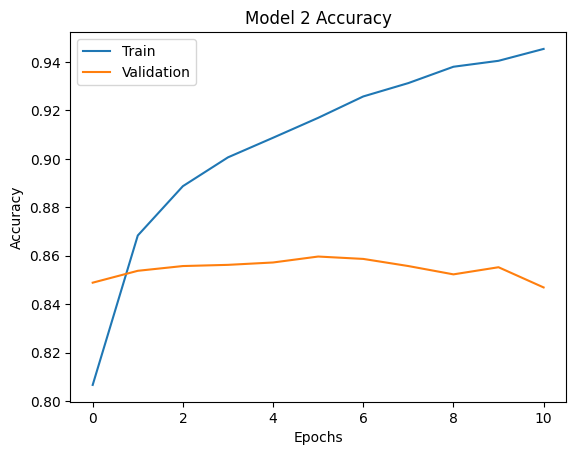

In [41]:
import matplotlib.pyplot as plt

plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])

plt.title('Model 2 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

The training accuracy increased steadily throughout the training process, reaching approximately 95%. However, the validation accuracy remained relatively stable around 85–86% and slightly decreased in later epochs. This suggests that the model learned the training data effectively but did not achieve comparable improvements on unseen validation data.

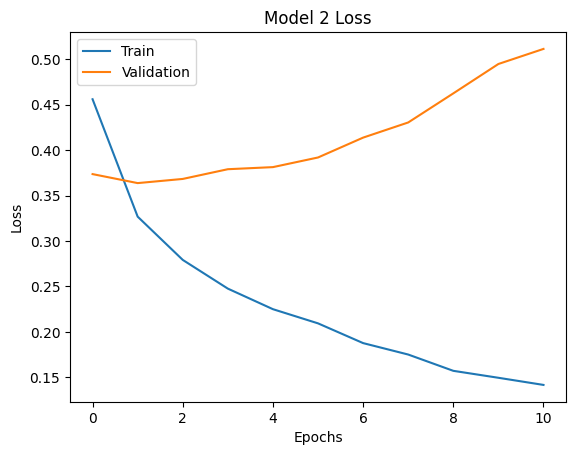

In [42]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

plt.title('Model 2 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

The training loss continuously decreased as training progressed, indicating that the model was fitting the training data well. In contrast, the validation loss increased after the first few epochs, suggesting that the model began to memorize patterns in the training data rather than generalizing to new data. This behavior indicates overfitting.

Evaluate Model 2

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.79      0.63      0.70       616
           1       0.89      0.95      0.92      1932

    accuracy                           0.87      2548
   macro avg       0.84      0.79      0.81      2548
weighted avg       0.86      0.87      0.86      2548



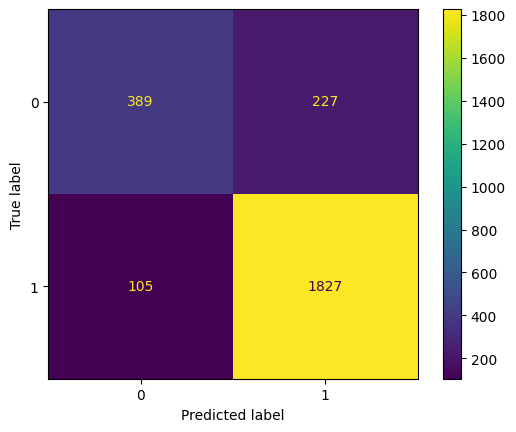

In [43]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred_prob2 = model2.predict(X_test_pca)

y_pred2 = (y_pred_prob2 > 0.5).astype(int)

print(classification_report(y_test, y_pred2))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred2
)

plt.show()

The confusion matrix shows that the model correctly classified 1,827 students who passed the course and 389 students who failed. However, 227 failing students were incorrectly predicted as passing, while 105 passing students were incorrectly predicted as failing. Overall, the model performs better at identifying students who pass the course than those who fail, which may be influenced by the class imbalance in the dataset.

Save Model 2 Accuracy for Comparison

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc2 = accuracy_score(y_test, y_pred2)
precision2 = precision_score(y_test, y_pred2)
recall2 = recall_score(y_test, y_pred2)
f12 = f1_score(y_test, y_pred2)

print("Model 2 Accuracy:", acc2)
print("Model 2 Precision:", precision2)
print("Model 2 Recall:", recall2)
print("Model 2 F1 Score:", f12)

Model 2 Accuracy: 0.869701726844584
Model 2 Precision: 0.8894839337877313
Model 2 Recall: 0.9456521739130435
Model 2 F1 Score: 0.916708479678876


Model 2 achieved an overall accuracy of approximately 87% on the test set. The model performed particularly well in identifying students who passed the course, achieving a recall of 95% for the positive class. However, performance on the failing students was lower, with a recall of 63%. The training and validation curves indicate some degree of overfitting, as validation loss increased while training loss continued to decrease. Despite this limitation, the model provides strong predictive performance and improves upon the basic architecture by incorporating an additional hidden layer and dropout regularization.

#Model 3: Deeper Neural Network with More Dropout

Build Model 3

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model3 = Sequential()

model3.add(Dense(
    128,
    activation='relu',
    input_shape=(X_train_pca.shape[1],)
))

model3.add(Dropout(0.4))

model3.add(Dense(
    64,
    activation='relu'
))

model3.add(Dropout(0.3))

model3.add(Dense(
    32,
    activation='relu'
))

model3.add(Dense(
    1,
    activation='sigmoid'
))

model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │        63,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,601 (287.50 KB)

 Trainable params: 73,601 (287.50 KB)

 Non-trainable params: 0 (0.00 B)

Train Model 3

In [46]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

history3 = model3.fit(
    X_train_pca,
    y_train,
    validation_split=0.2,
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7928 - loss: 0.4886 - val_accuracy: 0.8410 - val_loss: 0.3896
Epoch 2/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8565 - loss: 0.3591 - val_accuracy: 0.8553 - val_loss: 0.3670
Epoch 3/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8752 - loss: 0.3162 - val_accuracy: 0.8572 - val_loss: 0.3627
Epoch 4/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8839 - loss: 0.2884 - val_accuracy: 0.8597 - val_loss: 0.3722
Epoch 5/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8957 - loss: 0.2611 - val_accuracy: 0.8592 - val_loss: 0.3734
Epoch 6/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9031 - loss: 0.2455 - val_accuracy: 0.8562 - val_loss: 0.3799
Epoch 7/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9136 - loss: 0.2232 - val_accuracy: 0.8631 - val_loss: 0.3999
Epoch 8/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9193 - loss: 0.2109 - val_accuracy: 

Plot Model 3 Accuracy

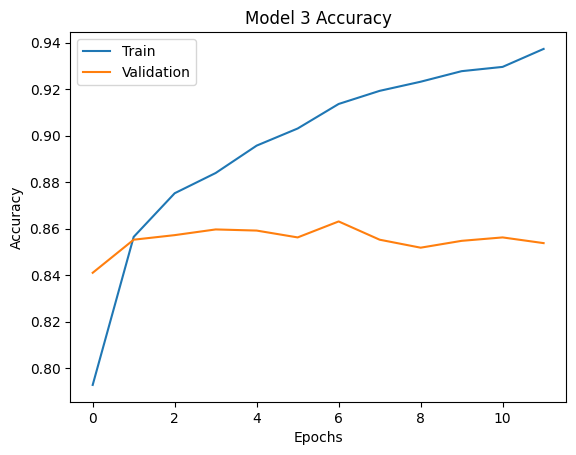

In [47]:
import matplotlib.pyplot as plt

plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])

plt.title('Model 3 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

Plot Model 3 Loss

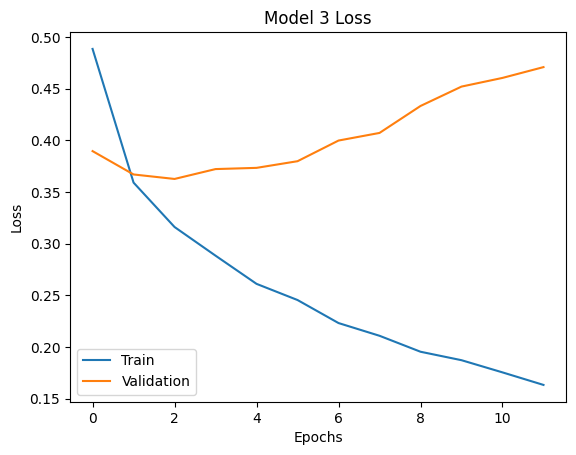

In [48]:
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])

plt.title('Model 3 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

The training accuracy continued to increase throughout the epochs, reaching approximately 94%, while the validation accuracy remained relatively stable around 85-86%.

At the same time, the training loss steadily decreased, whereas the validation loss increased after the first few epochs. This indicates that the model started to memorize the training data rather than learning patterns that generalize well to unseen data.

Therefore, Model 3 also suffers from overfitting. Increasing the network depth and adding additional neurons did not improve validation performance compared to Model 2.

Evaluate Model 3

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.78      0.63      0.69       616
           1       0.89      0.94      0.91      1932

    accuracy                           0.87      2548
   macro avg       0.83      0.78      0.80      2548
weighted avg       0.86      0.87      0.86      2548



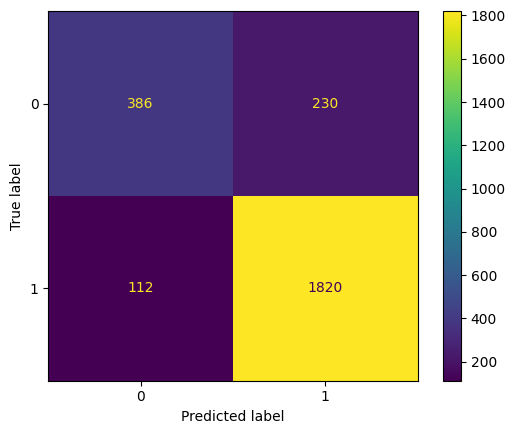

In [49]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred_prob3 = model3.predict(X_test_pca)

y_pred3 = (y_pred_prob3 > 0.5).astype(int)

print(classification_report(y_test, y_pred3))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred3
)

plt.show()

The confusion matrix shows that:

• 1820 students who passed were correctly classified as passing.
• 386 students who failed were correctly classified as failing.
• 230 failing students were incorrectly predicted as passing.
• 112 passing students were incorrectly predicted as failing.

Although the model is very effective at identifying successful students, it struggles more with identifying students who are at risk of failing. This suggests a bias toward predicting the majority class.

Save Model 3 Metrics

In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc3 = accuracy_score(y_test, y_pred3)
precision3 = precision_score(y_test, y_pred3)
recall3 = recall_score(y_test, y_pred3)
f13 = f1_score(y_test, y_pred3)

print("Model 3 Accuracy:", acc3)
print("Model 3 Precision:", precision3)
print("Model 3 Recall:", recall3)
print("Model 3 F1 Score:", f13)

Model 3 Accuracy: 0.8657770800627943
Model 3 Precision: 0.8878048780487805
Model 3 Recall: 0.9420289855072463
Model 3 F1 Score: 0.9141135107985937


Model 2 was selected as the final model because it achieved the best balance between accuracy, precision, recall, and F1-score. Although Model 3 was deeper and included additional regularization, it did not provide any meaningful improvement in validation or test performance. Therefore, Model 2 offers the most effective solution for predicting student success while maintaining a relatively simple architecture.

In [52]:
# Model 1 Predictions
y_pred1 = (model1.predict(X_test_pca) > 0.5).astype(int).flatten()

# Model 2 Predictions
y_pred2 = (model2.predict(X_test_pca) > 0.5).astype(int).flatten()

# Model 3 Predictions
y_pred3 = (model3.predict(X_test_pca) > 0.5).astype(int).flatten()

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

comparison_table = pd.DataFrame({
    'Model': ['Model 1', 'Model 2', 'Model 3'],

    'Accuracy': [
        accuracy_score(y_test, y_pred1),
        accuracy_score(y_test, y_pred2),
        accuracy_score(y_test, y_pred3)
    ],

    'Precision': [
        precision_score(y_test, y_pred1),
        precision_score(y_test, y_pred2),
        precision_score(y_test, y_pred3)
    ],

    'Recall': [
        recall_score(y_test, y_pred1),
        recall_score(y_test, y_pred2),
        recall_score(y_test, y_pred3)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred1),
        f1_score(y_test, y_pred2),
        f1_score(y_test, y_pred3)
    ]
})

comparison_table

,Model,Accuracy,Precision,Recall,F1 Score
0,Model 1,0.865777,0.890472,0.938406,0.913810
1,Model 2,0.869702,0.889484,0.945652,0.916708
2,Model 3,0.865777,0.887805,0.942029,0.914114


##Final Model Selection

###Interpretation

Model 2 achieved the best overall performance among all three models. It obtained the highest Accuracy (86.97%), Recall (94.57%), and F1 Score (91.67%), indicating a strong balance between identifying students who pass the course and minimizing classification errors.

Although Model 1 achieved slightly higher Precision, the difference was very small. Model 2 provided better overall predictive performance and generalization ability. Therefore, Model 2 was selected as the final model for solving the business problem.

##Business Problem Solution

The objective of this project was to predict whether a student will pass or fail a course based on their academic activity and assessment information.

The final selected model (Model 2) achieved an Accuracy of approximately 87% and a Recall of 94.57%. This means the model can successfully identify the majority of students who are likely to pass the course while maintaining a strong overall classification performance.

The model can be used by the online school to:

Identify students at risk of failing early.
Provide targeted academic support and interventions.
Improve student retention and success rates.
Help instructors monitor student performance more effectively.
Support data-driven decision making in educational planning.

Overall, the developed deep learning model provides a practical and effective solution for predicting student success and supporting educational decision-making.

#Model Improvement Justification
##Model 1

A basic neural network was created as the baseline model using two Dense layers. This model provided an initial benchmark for evaluating performance.

##Model 2

Additional neurons and a Dropout layer were introduced to improve feature learning and reduce overfitting. This modification increased the model's ability to generalize to unseen data and resulted in the highest performance among all models.

##Model 3

An additional hidden layer was added to increase model complexity and capture more complex relationships in the data. However, the improvement was limited and the model showed signs of overfitting, resulting in slightly lower performance than Model 2.

##Therefore, Model 2 was selected as the final model.#

## Code Resources

- TensorFlow Documentation: https://www.tensorflow.org/
- Scikit-Learn Documentation: https://scikit-learn.org/
- Pandas Documentation: https://pandas.pydata.org/
- NumPy Documentation: https://numpy.org/
- Matplotlib Documentation: https://matplotlib.org/
- Seaborn Documentation: https://seaborn.pydata.org/